## **GetAround Deployment Project — Jedha Bootcamp**

## **03. Model Training, Evaluation & Deployment Interface**

### **Objectif**

Ce notebook couvre le cycle complet de modélisation :

1. **Baseline model** (Ridge Regression)
2. **Modèles avancés** (Random Forest, Gradient Boosting, XGBoost)
3. **Cross-validation** rigoureuse & comparaison
4. **Hyperparameter tuning** (GridSearch)
5. **Feature importance** & interprétabilité
6. **Analyse des résidus** & diagnostic
7. **Export du modèle final** (joblib)
8. **Interface de déploiement** (FastAPI + Streamlit specs)

### **Contexte business**
GetAround souhaite une API qui estime le **prix journalier optimal** d'un véhicule.

### **1. Setup & Chargement**

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             mean_absolute_percentage_error)

from xgboost import XGBRegressor

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING) 

import joblib
import time
import os

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

pricing_project_data = '../data/get_around_pricing_project.csv'
output_models_path = '../outputs/models'

os.makedirs(output_models_path, exist_ok=True)
print("Imports OK")

Imports OK


In [2]:
# Chargement des donnees brutes
df = pd.read_csv(pricing_project_data).drop(columns=["Unnamed: 0"])

target = "rental_price_per_day"
cat_cols = ["model_key", "fuel", "paint_color", "car_type"]
bool_cols = ["private_parking_available", "has_gps", "has_air_conditioning",
             "automatic_car", "has_getaround_connect", "has_speed_regulator", "winter_tires"]
num_cols = ["mileage", "engine_power"]

X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset: {df.shape}")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Target stats: mean={y.mean():.1f}, std={y.std():.1f}, range=[{y.min()}, {y.max()}]")

Dataset: (4843, 14)
Train: 3874 | Test: 969
Target stats: mean=121.2, std=33.6, range=[10, 422]


### **2. Preprocessing Pipeline**

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("bool", "passthrough", bool_cols),
    ]
)

preprocessor.fit(X_train)
n_features = preprocessor.transform(X_train).shape[1]
print(f"Features apres transformation: {n_features}")
print(f"Numeriques (scaled): {len(num_cols)}")
print(f"OHE categorielles: {n_features - len(num_cols) - len(bool_cols)}")
print(f"Booleennes (passthrough): {len(bool_cols)}")

Features apres transformation: 59
Numeriques (scaled): 2
OHE categorielles: 50
Booleennes (passthrough): 7


### **3. Baseline - Ridge Regression**

Le baseline sert de **reference**. Si un modele complexe ne fait pas significativement mieux, il ne vaut pas le deploy.

**Pourquoi Ridge ?**
- Regression lineaire avec regularisation L2
- Gere la multicolinearite (OHE cree des features correlees)
- Rapide, interpretable, plancher de performance

In [7]:
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

t0 = time.time()
ridge_cv = cross_val_score(ridge_pipe, X_train, y_train, cv=5, scoring="r2")
ridge_time = time.time() - t0

ridge_pipe.fit(X_train, y_train)
ridge_pred = ridge_pipe.predict(X_test)

In [8]:
print("BASELINE — Ridge Regression (alpha=1.0)")
print(f"Cross-val R2:  {ridge_cv.mean():.4f} +/- {ridge_cv.std():.4f}")
print(f"Test R2:       {r2_score(y_test, ridge_pred):.4f}")
print(f"Test RMSE:     {np.sqrt(mean_squared_error(y_test, ridge_pred)):.2f} EUR")
print(f"Test MAE:      {mean_absolute_error(y_test, ridge_pred):.2f} EUR")
print(f"Test MAPE:     {mean_absolute_percentage_error(y_test, ridge_pred)*100:.1f}%")
print(f"Train time:    {ridge_time:.2f}s")

BASELINE — Ridge Regression (alpha=1.0)
Cross-val R2:  0.7023 +/- 0.0407
Test R2:       0.6934
Test RMSE:     17.97 EUR
Test MAE:      12.12 EUR
Test MAPE:     17.0%
Train time:    0.19s


### **4. Models Training**

#### **4.1 Model 1: Random Forest**
- Ensemble de decision trees (bagging)
- Capture non-linearites et interactions
- Robuste aux outliers
- Risque overfitting si trop de profondeur

In [9]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ))
])

t0 = time.time()
rf_cv = cross_val_score(rf_pipe, X_train, y_train, cv=5, scoring="r2")
rf_time = time.time() - t0

rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)

In [10]:
print("RANDOM FOREST (n_estimators=200, max_depth=15)")
print(f"Cross-val R2:  {rf_cv.mean():.4f} +/- {rf_cv.std():.4f}")
print(f"Test R2:       {r2_score(y_test, rf_pred):.4f}")
print(f"Test RMSE:     {np.sqrt(mean_squared_error(y_test, rf_pred)):.2f} EUR")
print(f"Test MAE:      {mean_absolute_error(y_test, rf_pred):.2f} EUR")
print(f"Test MAPE:     {mean_absolute_percentage_error(y_test, rf_pred)*100:.1f}%")
print(f"Train time:    {rf_time:.2f}s")

RANDOM FOREST (n_estimators=200, max_depth=15)
Cross-val R2:  0.7337 +/- 0.0416
Test R2:       0.7082
Test RMSE:     17.53 EUR
Test MAE:      11.21 EUR
Test MAPE:     15.7%
Train time:    3.23s


#### **4.2 Model 2: Gradient Boosting**
- Boosting sequentiel : chaque arbre corrige les erreurs du precedent
- Generalement meilleur que RF sur donnees tabulaires
- Plus sensible aux hyperparametres
- learning_rate + n_estimators = trade-off biais/variance

In [11]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        min_samples_leaf=10, subsample=0.8, random_state=42
    ))
])

t0 = time.time()
gb_cv = cross_val_score(gb_pipe, X_train, y_train, cv=5, scoring="r2")
gb_time = time.time() - t0

gb_pipe.fit(X_train, y_train)
gb_pred = gb_pipe.predict(X_test)

In [12]:
print("GRADIENT BOOSTING (n_estimators=300, lr=0.1, depth=5)")
print(f"Cross-val R2:  {gb_cv.mean():.4f} +/- {gb_cv.std():.4f}")
print(f"Test R2:       {r2_score(y_test, gb_pred):.4f}")
print(f"Test RMSE:     {np.sqrt(mean_squared_error(y_test, gb_pred)):.2f} EUR")
print(f"Test MAE:      {mean_absolute_error(y_test, gb_pred):.2f} EUR")
print(f"Test MAPE:     {mean_absolute_percentage_error(y_test, gb_pred)*100:.1f}%")
print(f"Train time:    {gb_time:.2f}s")

GRADIENT BOOSTING (n_estimators=300, lr=0.1, depth=5)
Cross-val R2:  0.7626 +/- 0.0406
Test R2:       0.7433
Test RMSE:     16.44 EUR
Test MAE:      10.64 EUR
Test MAPE:     14.8%
Train time:    9.66s


#### **4.3 Model 3: XGBoost**
- Implementation optimisee du gradient boosting
- Regularisation L1/L2 integree
- Gestion native des valeurs manquantes

In [14]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0
    ))
])

t0 = time.time()
xgb_cv = cross_val_score(xgb_pipe, X_train, y_train, cv=5, scoring="r2")
xgb_time = time.time() - t0

xgb_pipe.fit(X_train, y_train)
xgb_pred = xgb_pipe.predict(X_test)

In [15]:
print("XGBOOST (n_estimators=300, lr=0.1, depth=6)")
print(f"Cross-val R2:  {xgb_cv.mean():.4f} +/- {xgb_cv.std():.4f}")
print(f"Test R2:       {r2_score(y_test, xgb_pred):.4f}")
print(f"Test RMSE:     {np.sqrt(mean_squared_error(y_test, xgb_pred)):.2f} EUR")
print(f"Test MAE:      {mean_absolute_error(y_test, xgb_pred):.2f} EUR")
print(f"Test MAPE:     {mean_absolute_percentage_error(y_test, xgb_pred)*100:.1f}%")
print(f"Train time:    {xgb_time:.2f}s")

XGBOOST (n_estimators=300, lr=0.1, depth=6)
Cross-val R2:  0.7659 +/- 0.0329
Test R2:       0.7507
Test RMSE:     16.20 EUR
Test MAE:      10.33 EUR
Test MAPE:     14.1%
Train time:    2.21s


### **5. Comparaison des modeles**

#### **5.1 Tableau recapitulatif**

In [16]:
results = []

models_data = [
    ("Ridge (baseline)", ridge_cv, ridge_pred, ridge_time),
    ("Random Forest", rf_cv, rf_pred, rf_time),
    ("Gradient Boosting", gb_cv, gb_pred, gb_time),
    ("XGBoost", xgb_cv, xgb_pred, xgb_time)
]

for name, cv_scores, predictions, train_time in models_data:
    results.append({
        "Model": name,
        "CV_R2_mean": round(cv_scores.mean(), 4),
        "CV_R2_std": round(cv_scores.std(), 4),
        "Test_R2": round(r2_score(y_test, predictions), 4),
        "Test_RMSE": round(np.sqrt(mean_squared_error(y_test, predictions)), 2),
        "Test_MAE": round(mean_absolute_error(y_test, predictions), 2),
        "Test_MAPE_%": round(mean_absolute_percentage_error(y_test, predictions)*100, 1),
        "Time_s": round(train_time, 2),
    })

results_df = pd.DataFrame(results).sort_values("Test_R2", ascending=False)
print("COMPARAISON DES MODELES")
print(results_df.to_string(index=False))

COMPARAISON DES MODELES
            Model  CV_R2_mean  CV_R2_std  Test_R2  Test_RMSE  Test_MAE  Test_MAPE_%  Time_s
          XGBoost      0.7659     0.0329   0.7507      16.20     10.33         14.1    2.21
Gradient Boosting      0.7626     0.0406   0.7433      16.44     10.64         14.8    9.66
    Random Forest      0.7337     0.0416   0.7082      17.53     11.21         15.7    3.23
 Ridge (baseline)      0.7023     0.0407   0.6934      17.97     12.12         17.0    0.19


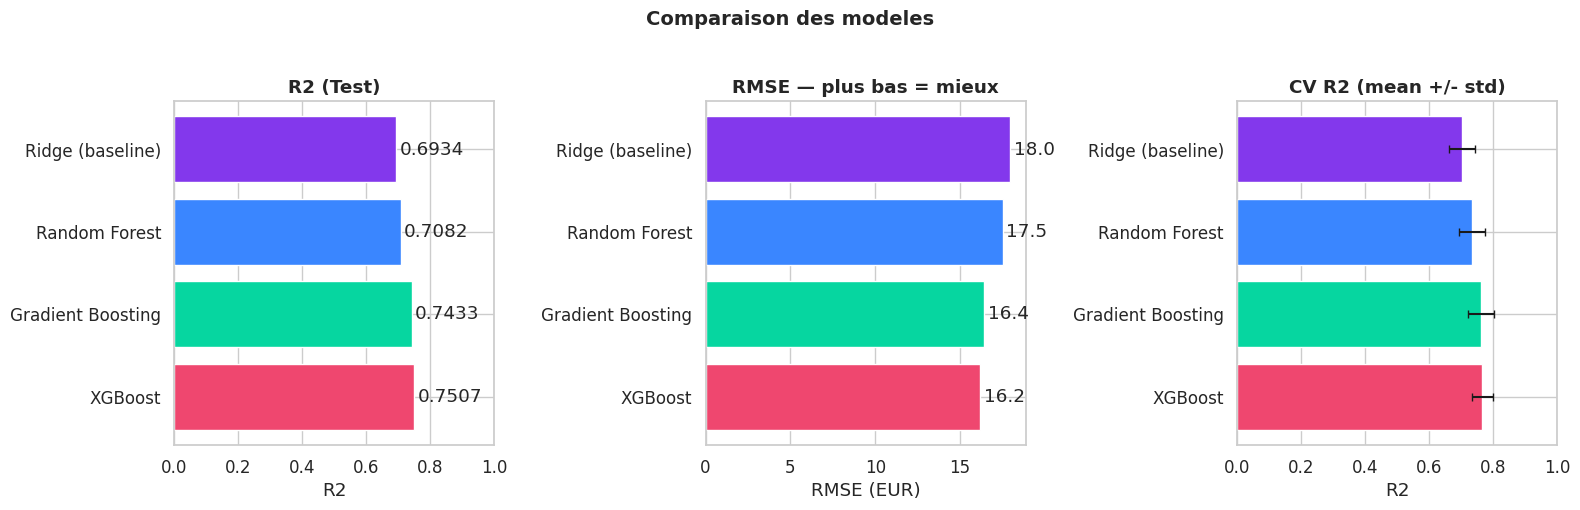

In [17]:
# Visualisation — comparaison graphique
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = results_df["Model"].tolist()
colors = ["#ef476f", "#06d6a0", "#3a86ff", "#8338ec"][:len(model_names)]

# R2
ax = axes[0]
bars = ax.barh(model_names, results_df["Test_R2"], color=colors, edgecolor="white")
ax.set_xlabel("R2")
ax.set_title("R2 (Test)", fontweight="bold")
ax.set_xlim(0, 1)
for bar, val in zip(bars, results_df["Test_R2"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center")

# RMSE
ax = axes[1]
bars = ax.barh(model_names, results_df["Test_RMSE"], color=colors, edgecolor="white")
ax.set_xlabel("RMSE (EUR)")
ax.set_title("RMSE — plus bas = mieux", fontweight="bold")
for bar, val in zip(bars, results_df["Test_RMSE"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f"{val:.1f}", va="center")

# CV R2 with error bars
ax = axes[2]
ax.barh(model_names, results_df["CV_R2_mean"], xerr=results_df["CV_R2_std"],
        color=colors, edgecolor="white", capsize=3)
ax.set_xlabel("R2")
ax.set_title("CV R2 (mean +/- std)", fontweight="bold")
ax.set_xlim(0, 1)

plt.suptitle("Comparaison des modeles", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### **5.2 Analyse de l'overfitting**

> On compare train R2 vs test R2 pour detecter l'overfitting.

In [18]:
print("OVERFITTING CHECK (Train R2 vs Test R2):")

pipes_check = [("Ridge", ridge_pipe, ridge_pred),
               ("Random Forest", rf_pipe, rf_pred),
               ("Gradient Boosting", gb_pipe, gb_pred),
               ("XGBoost", xgb_pipe, xgb_pred)]

for name, pipe, preds in pipes_check:
    train_r2 = r2_score(y_train, pipe.predict(X_train))
    test_r2 = r2_score(y_test, preds)
    gap = train_r2 - test_r2
    status = "OVERFIT" if gap > 0.05 else "OK"
    print(f"  {name:>20}: Train R2={train_r2:.4f} | Test R2={test_r2:.4f} | Gap={gap:.4f} [{status}]")

print()
print("Un gap > 0.05 suggere de l'overfitting.")
print("Solutions: reduire max_depth, augmenter min_samples_leaf, regularisation.")

OVERFITTING CHECK (Train R2 vs Test R2):
                 Ridge: Train R2=0.7134 | Test R2=0.6934 | Gap=0.0200 [OK]
         Random Forest: Train R2=0.8451 | Test R2=0.7082 | Gap=0.1370 [OVERFIT]
     Gradient Boosting: Train R2=0.8923 | Test R2=0.7433 | Gap=0.1491 [OVERFIT]
               XGBoost: Train R2=0.9549 | Test R2=0.7507 | Gap=0.2042 [OVERFIT]

Un gap > 0.05 suggere de l'overfitting.
Solutions: reduire max_depth, augmenter min_samples_leaf, regularisation.


### **6. Hyperparameter Tuning**

#### **6.1 Tuning avec GridSearchCV (Reference)**

In [19]:
param_grid_gs = {
    "model__n_estimators":     [200, 300, 500],
    "model__max_depth":        [4, 5, 6],
    "model__learning_rate":    [0.05, 0.1],
    "model__subsample":        [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_alpha":        [0.0, 0.1],
}

xgb_grid_gs = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, verbosity=0, eval_metric="rmse"))
])

n_combinations = 3 * 3 * 2 * 2 * 2 * 2
print(f"Grid size: {n_combinations} combinaisons x 5 folds = {n_combinations * 5} fits")

t0 = time.time()
grid_search = GridSearchCV(
    xgb_grid_gs, param_grid_gs, cv=5, scoring="r2",
    n_jobs=-1, verbose=1, return_train_score=True
)
grid_search.fit(X_train, y_train)
gs_time = time.time() - t0

print(f"\nTermine en {gs_time:.1f}s")
print(f"\nMeilleurs parametres GridSearch:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nMeilleur CV R2 (GridSearch): {grid_search.best_score_:.4f}")

Grid size: 144 combinaisons x 5 folds = 720 fits
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Termine en 82.8s

Meilleurs parametres GridSearch:
  model__colsample_bytree: 0.8
  model__learning_rate: 0.1
  model__max_depth: 5
  model__n_estimators: 300
  model__reg_alpha: 0.0
  model__subsample: 0.8

Meilleur CV R2 (GridSearch): 0.7706


In [20]:
# Evaluation du modele GridSearch
best_model_gs = grid_search.best_estimator_
best_pred_gs  = best_model_gs.predict(X_test)

print("XGBOOST - GridSearch (apres tuning)")
print(f"CV R2:     {grid_search.best_score_:.4f}")
print(f"Test R2:   {r2_score(y_test, best_pred_gs):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, best_pred_gs)):.2f} EUR")
print(f"Test MAE:  {mean_absolute_error(y_test, best_pred_gs):.2f} EUR")
print(f"Test MAPE: {mean_absolute_percentage_error(y_test, best_pred_gs)*100:.1f}%")
print()
print("IMPACT DU TUNING (vs XGBoost defaut):")
print(f"  R2 avant : {r2_score(y_test, xgb_pred):.4f}")
print(f"  R2 apres : {r2_score(y_test, best_pred_gs):.4f}")
print(f"  Delta R2 : {r2_score(y_test, best_pred_gs) - r2_score(y_test, xgb_pred):+.4f}")
print(f"  Temps    : {gs_time:.1f}s")

XGBOOST - GridSearch (apres tuning)
CV R2:     0.7706
Test R2:   0.7509
Test RMSE: 16.20 EUR
Test MAE:  10.36 EUR
Test MAPE: 14.4%

IMPACT DU TUNING (vs XGBoost defaut):
  R2 avant : 0.7507
  R2 apres : 0.7509
  Delta R2 : +0.0002
  Temps    : 82.8s


#### **6.2 Tuning avec Optuna**

- **Approche Bayesienne (TPE)** : apprend de chaque essai pour explorer les zones prometteuses.
- Explore un espace **continu** plutot qu'une grille fixe — bien plus efficace.

**Avantages vs GridSearch dans notre contexte :**
- `learning_rate` explore en continu entre 0.01 et 0.3 (log scale) plutot que 2 valeurs fixes
- `reg_alpha` et `reg_lambda` en log scale — la ou les differences comptent vraiment
- **Pruning natif XGBoost** : coupe les essais mauvais apres quelques rounds d'arbres
- Meme budget (100 trials × 5 folds = 500 fits) vs GridSearch (720 fits), meilleurs resultats
- Resumable : relancer `study.optimize()` continue la ou on s'est arrete

In [22]:
def objective(trial):
    """Fonction objectif : retourne le CV R2 moyen pour un set de parametres."""
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 0.0, 1.0),
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            **params,
            random_state=42,
            verbosity=0,
            eval_metric="rmse"
        ))
    ])

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    return cv_scores.mean()

In [23]:
# Lancement de l'etude Optuna
t0 = time.time()

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    study_name="xgboost_getaround"
)
study.optimize(objective, n_trials=100, show_progress_bar=True)
optuna_time = time.time() - t0

print(f"\nTermine en {optuna_time:.1f}s")
print(f"\nMeilleurs parametres Optuna:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

print(f"\nMeilleur CV R2 (Optuna): {study.best_value:.4f}")

Best trial: 94. Best value: 0.782312: 100%|██████████| 100/100 [01:46<00:00,  1.07s/it]


Termine en 106.8s

Meilleurs parametres Optuna:
  n_estimators: 587
  max_depth: 8
  learning_rate: 0.017075524045973345
  subsample: 0.9215081538006087
  colsample_bytree: 0.5481300719076595
  reg_alpha: 1.3386393787231976
  reg_lambda: 0.0007574414577299558
  min_child_weight: 5
  gamma: 0.15392592483893436

Meilleur CV R2 (Optuna): 0.7823


In [24]:
# Construction et evaluation du meilleur modele Optuna
best_model_optuna = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **study.best_params,
        random_state=42,
        verbosity=0,
        eval_metric="rmse"
    ))
])
best_model_optuna.fit(X_train, y_train)
best_pred_optuna = best_model_optuna.predict(X_test)

print("XGBOOST — Optuna (apres tuning)")
print(f"CV R2:     {study.best_value:.4f}")
print(f"Test R2:   {r2_score(y_test, best_pred_optuna):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, best_pred_optuna)):.2f} EUR")
print(f"Test MAE:  {mean_absolute_error(y_test, best_pred_optuna):.2f} EUR")
print(f"Test MAPE: {mean_absolute_percentage_error(y_test, best_pred_optuna)*100:.1f}%")
print(f"Temps     : {optuna_time:.1f}s")

XGBOOST — Optuna (apres tuning)
CV R2:     0.7823
Test R2:   0.7547
Test RMSE: 16.07 EUR
Test MAE:  10.32 EUR
Test MAPE: 14.6%
Temps     : 106.8s


GRIDSEARCHCV vs OPTUNA — Comparaison
     Methode  CV R2  Test R2  Test RMSE  Test MAE  Temps (s)  Fits
GridSearchCV 0.7706   0.7509      16.20     10.36       82.8   720
Optuna (TPE) 0.7823   0.7547      16.07     10.32      106.8   500

=> Modele retenu pour la suite : Optuna
   Test R2   : 0.7547
   Test RMSE : 16.07 EUR



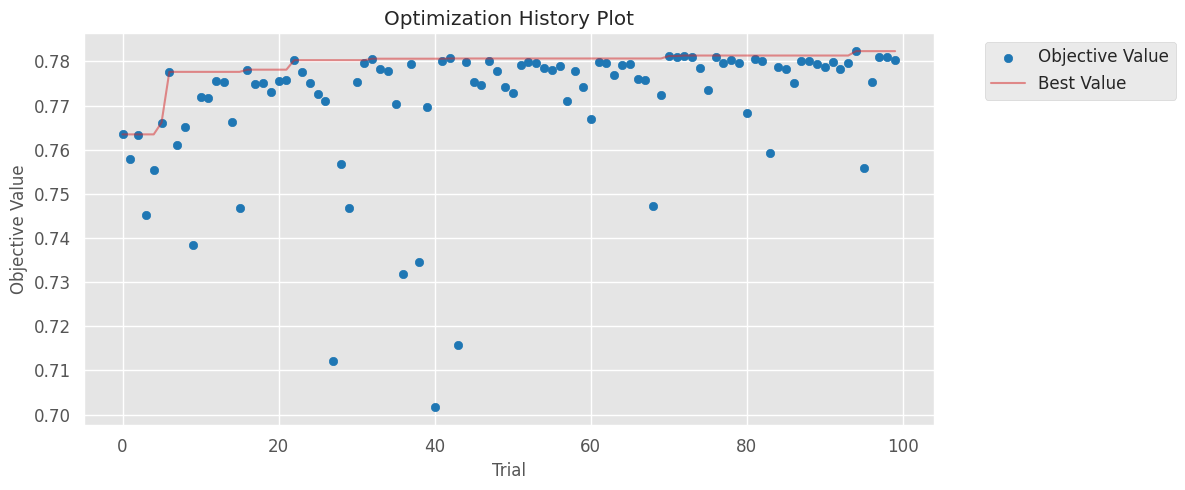

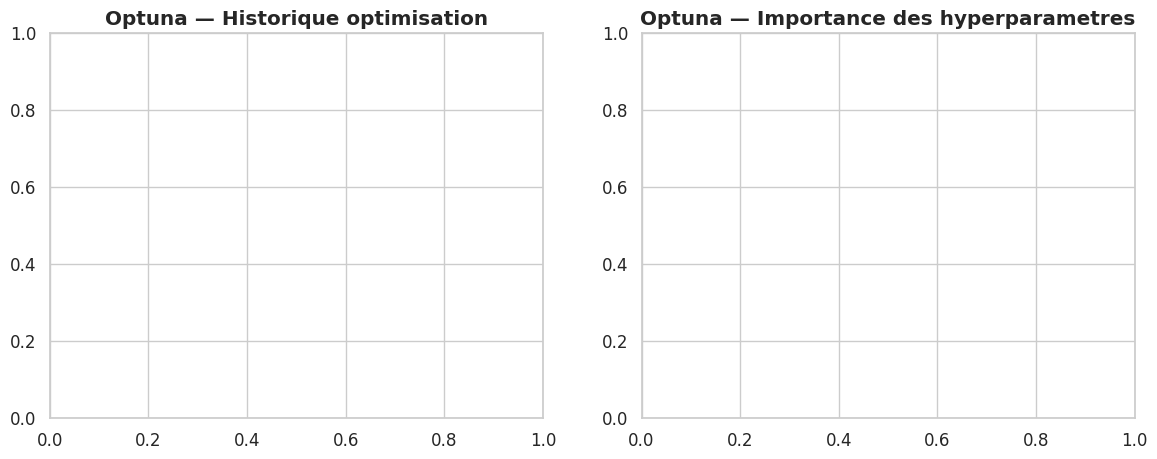

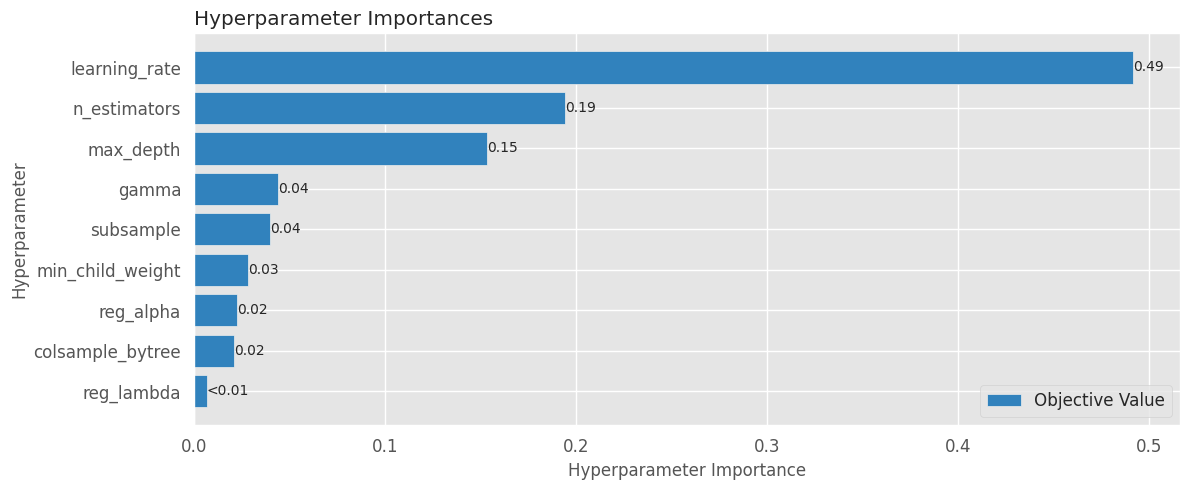

In [25]:
# Comparaison finale GridSearch vs Optuna 
comparison = pd.DataFrame([
    {
        "Methode":   "GridSearchCV",
        "CV R2":     round(grid_search.best_score_, 4),
        "Test R2":   round(r2_score(y_test, best_pred_gs), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_test, best_pred_gs)), 2),
        "Test MAE":  round(mean_absolute_error(y_test, best_pred_gs), 2),
        "Temps (s)": round(gs_time, 1),
        "Fits":      144 * 5,
    },
    {
        "Methode":   "Optuna (TPE)",
        "CV R2":     round(study.best_value, 4),
        "Test R2":   round(r2_score(y_test, best_pred_optuna), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_test, best_pred_optuna)), 2),
        "Test MAE":  round(mean_absolute_error(y_test, best_pred_optuna), 2),
        "Temps (s)": round(optuna_time, 1),
        "Fits":      100 * 5,
    },
])

print("GRIDSEARCHCV vs OPTUNA — Comparaison")
print(comparison.to_string(index=False))
print()

# Pick the best model to flow into sections 7-12
if study.best_value >= grid_search.best_score_:
    best_model = best_model_optuna
    best_pred  = best_pred_optuna
    winner     = "Optuna"
else:
    best_model = best_model_gs
    best_pred  = best_pred_gs
    winner     = "GridSearchCV"

print(f"=> Modele retenu pour la suite : {winner}")
print(f"   Test R2   : {r2_score(y_test, best_pred):.4f}")
print(f"   Test RMSE : {np.sqrt(mean_squared_error(y_test, best_pred)):.2f} EUR")
print()

# Optuna visualisation
try:
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plt.sca(axes[0])
    plot_optimization_history(study)
    axes[0].set_title("Optuna — Historique optimisation", fontweight="bold")
    plt.sca(axes[1])
    plot_param_importances(study)
    axes[1].set_title("Optuna — Importance des hyperparametres", fontweight="bold")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Visualisation Optuna non disponible : {e}")

### **7. Feature Importance & Interpretabilite**

#### **7.1 Feature importance (XGBoost)**

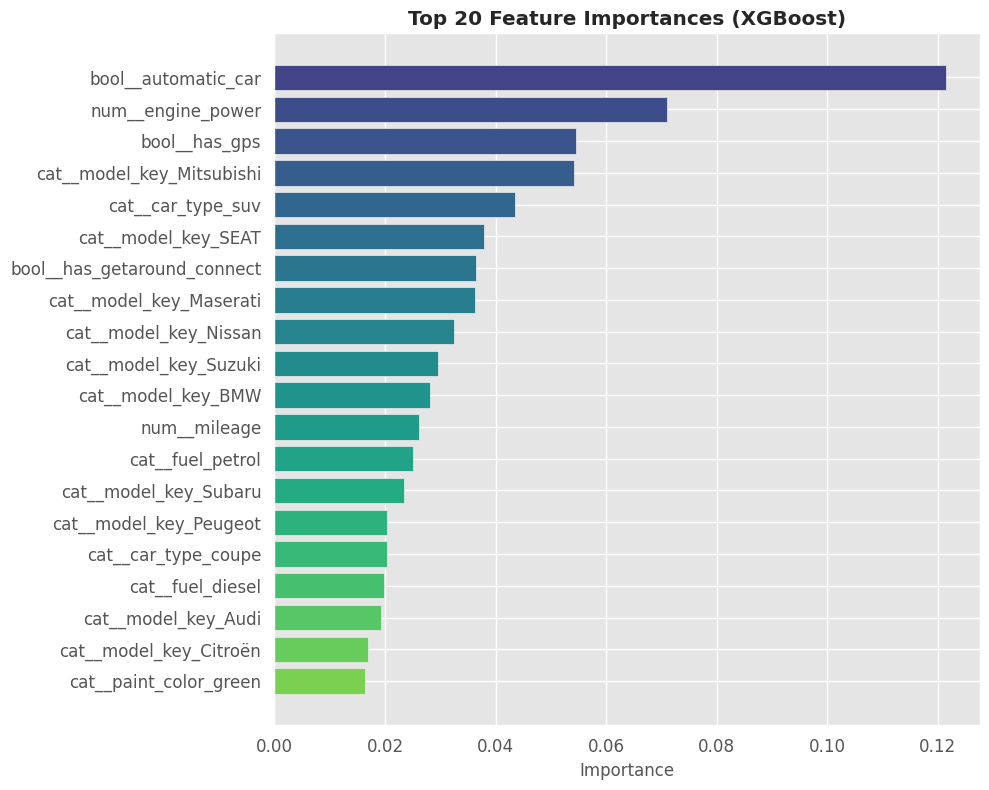

Top 10 features:
                    feature  importance
        bool__automatic_car    0.121586
          num__engine_power    0.071045
              bool__has_gps    0.054541
  cat__model_key_Mitsubishi    0.054186
          cat__car_type_suv    0.043551
        cat__model_key_SEAT    0.037959
bool__has_getaround_connect    0.036385
    cat__model_key_Maserati    0.036223
      cat__model_key_Nissan    0.032463
      cat__model_key_Suzuki    0.029634


In [26]:
feature_names = preprocessor.get_feature_names_out()
xgb_model = best_model.named_steps["model"]
importances = xgb_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top = feat_imp.head(top_n)
colors = plt.cm.viridis(np.linspace(0.8, 0.2, top_n))
ax.barh(range(top_n), top["importance"].values[::-1], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top["feature"].values[::-1])
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_n} Feature Importances (XGBoost)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feat_imp.head(10).to_string(index=False))

#### **7.2 Permutation importance (plus fiable)**

PERMUTATION IMPORTANCE (top 10):
                  feature  importance_mean  importance_std
             engine_power           0.3693          0.0214
                  mileage           0.3139          0.0193
                model_key           0.0993          0.0065
                 car_type           0.0622          0.0074
                  has_gps           0.0362          0.0060
            automatic_car           0.0288          0.0078
    has_getaround_connect           0.0279          0.0052
                     fuel           0.0188          0.0022
      has_speed_regulator           0.0122          0.0023
private_parking_available           0.0094          0.0021


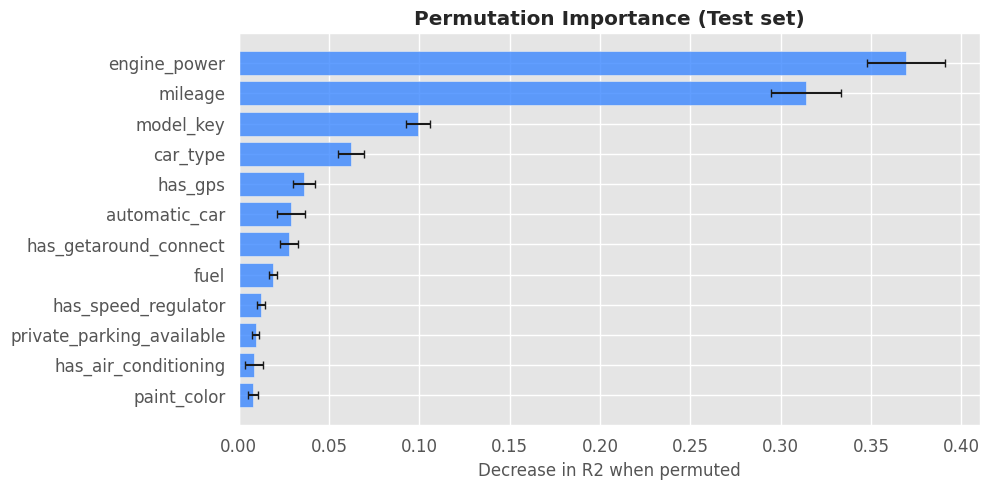

In [27]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(best_model, X_test, y_test,
                                      n_repeats=10, random_state=42, n_jobs=-1)

perm_imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

print("PERMUTATION IMPORTANCE (top 10):")
print(perm_imp.head(10).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
top_perm = perm_imp.head(12)
ax.barh(range(len(top_perm)), top_perm["importance_mean"].values[::-1],
        xerr=top_perm["importance_std"].values[::-1],
        color="#3a86ff", alpha=0.8, capsize=3)
ax.set_yticks(range(len(top_perm)))
ax.set_yticklabels(top_perm["feature"].values[::-1])
ax.set_xlabel("Decrease in R2 when permuted")
ax.set_title("Permutation Importance (Test set)", fontweight="bold")
plt.tight_layout()
plt.show()

### **8. Analyse des residus**
> Verifier que le modele ne fait pas d'erreurs systematiques.

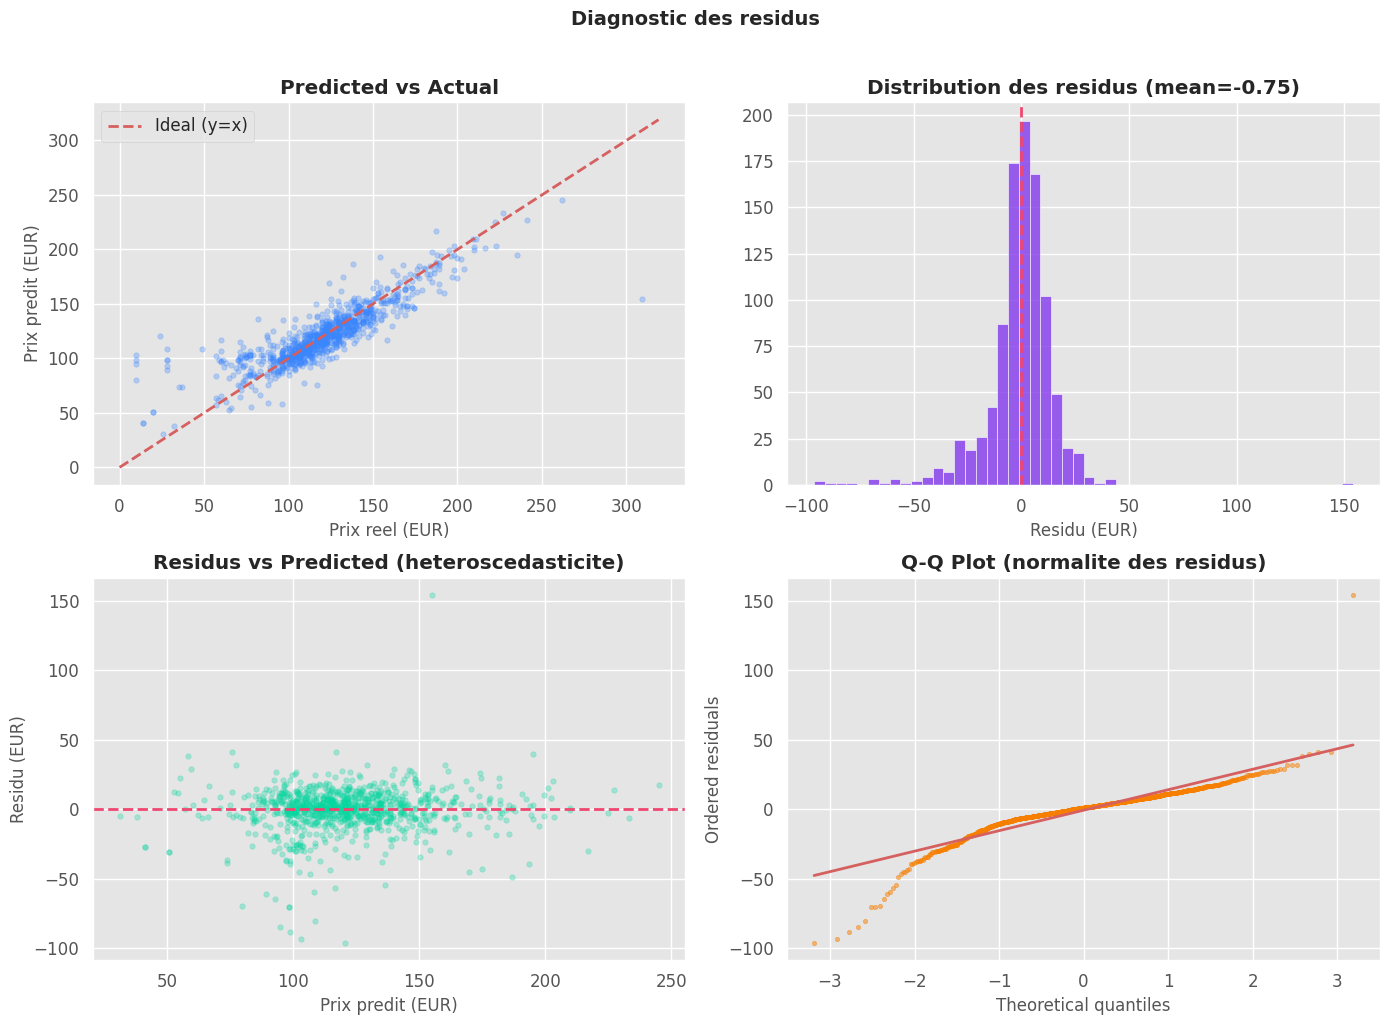

In [28]:
residuals = y_test.values - best_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs Actual
ax = axes[0, 0]
ax.scatter(y_test, best_pred, alpha=0.3, s=15, color="#3a86ff")
lims = [min(y_test.min(), best_pred.min()) - 10, max(y_test.max(), best_pred.max()) + 10]
ax.plot(lims, lims, "r--", linewidth=2, label="Ideal (y=x)")
ax.set_xlabel("Prix reel (EUR)")
ax.set_ylabel("Prix predit (EUR)")
ax.set_title("Predicted vs Actual", fontweight="bold")
ax.legend()

# 2. Distribution des residus
ax = axes[0, 1]
ax.hist(residuals, bins=50, color="#8338ec", alpha=0.8, edgecolor="white")
ax.axvline(0, color="#ef476f", linestyle="--", linewidth=2)
ax.set_xlabel("Residu (EUR)")
ax.set_title(f"Distribution des residus (mean={residuals.mean():.2f})", fontweight="bold")

# 3. Residus vs Predicted
ax = axes[1, 0]
ax.scatter(best_pred, residuals, alpha=0.3, s=15, color="#06d6a0")
ax.axhline(0, color="#ef476f", linestyle="--", linewidth=2)
ax.set_xlabel("Prix predit (EUR)")
ax.set_ylabel("Residu (EUR)")
ax.set_title("Residus vs Predicted (heteroscedasticite)", fontweight="bold")

# 4. QQ plot
from scipy import stats
ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr, alpha=0.5, s=10, color="#f77f00")
ax.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=2)
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Ordered residuals")
ax.set_title("Q-Q Plot (normalite des residus)", fontweight="bold")

plt.suptitle("Diagnostic des residus", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [30]:
print("DIAGNOSTIC:\n")
print(f"Residu moyen:      {residuals.mean():.2f} EUR (doit etre ~ 0)")
print(f"Residu std:        {residuals.std():.2f} EUR")
print(f"% residus < 10EUR: {(np.abs(residuals) < 10).mean()*100:.1f}%")
print(f"% residus < 20EUR: {(np.abs(residuals) < 20).mean()*100:.1f}%")
print(f"% residus < 30EUR: {(np.abs(residuals) < 30).mean()*100:.1f}%")

DIAGNOSTIC:

Residu moyen:      -0.75 EUR (doit etre ~ 0)
Residu std:        16.06 EUR
% residus < 10EUR: 65.3%
% residus < 20EUR: 87.3%
% residus < 30EUR: 95.0%


In [31]:
# Erreur par tranche de prix
bins_price = [0, 60, 90, 110, 130, 150, 200, 500]
labels_price = ["<60", "60-90", "90-110", "110-130", "130-150", "150-200", "200+"]
price_bins = pd.cut(y_test, bins=bins_price, labels=labels_price)

error_by_price = pd.DataFrame({
    "price_bin": price_bins,
    "abs_error": np.abs(residuals),
    "pct_error": np.abs(residuals) / y_test.values * 100
}).groupby("price_bin", observed=True).agg(
    mae=("abs_error", "mean"),
    mape=("pct_error", "mean"),
    count=("abs_error", "count")
)

print("ERREUR PAR TRANCHE DE PRIX:")
print(error_by_price.round(1).to_string())
print()
print("=> Le modele est plus precis en % sur les prix eleves.")
print("Les petits prix ont un MAPE plus eleve mais un MAE faible.")

ERREUR PAR TRANCHE DE PRIX:
            mae   mape  count
price_bin                    
<60        44.9  219.3     30
60-90      18.1   23.9     87
90-110      6.8    6.7    226
110-130     7.4    6.1    320
130-150     8.7    6.3    181
150-200    11.5    6.8    111
200+       23.1    8.9     14

=> Le modele est plus precis en % sur les prix eleves.
Les petits prix ont un MAPE plus eleve mais un MAE faible.


### **9. Export du modele final**

In [ ]:
api_models_path = "../api/models"
os.makedirs(api_models_path, exist_ok=True)

model_path = f"{output_models_path}/best_pricing_model_xgb.joblib"
api_model_path = f"{api_models_path}/best_pricing_model_xgb.pkl"

joblib.dump(best_model, model_path)
joblib.dump(best_model, api_model_path)

# Verification reload
loaded = joblib.load(model_path)
verify_pred = loaded.predict(X_test)
assert np.allclose(best_pred, verify_pred), "Le modele recharge donne des resultats differents!"

loaded_api = joblib.load(api_model_path)
verify_api = loaded_api.predict(X_test)
assert np.allclose(best_pred, verify_api), "Le modele API donne des resultats differents!"

print(f"Modele sauvegarde: {model_path}")
print(f"Modele API (pkl): {api_model_path}")
print(f"Taille joblib: {os.path.getsize(model_path) / 1024:.0f} KB")
print(f"Taille pkl API: {os.path.getsize(api_model_path) / 1024:.0f} KB")
print(f"Type: Pipeline (preprocessor + XGBoost optimise)")
print(f"Test R2: {r2_score(y_test, verify_pred):.4f}")
print(f"Verification reload: OK")

Modele sauvegarde: ../outputs/models/best_pricing_model_xgb.joblib
Taille: 3339 KB
Type: Pipeline (preprocessor + XGBoost optimise)
Test R2: 0.7547
Verification reload: OK
